# ETFs: Model-Based Features (Per-Fold Temporal Models)

This notebook fits temporal models and extracts features that capture
latent market dynamics. All models are fit **per CV fold** on training
data only, eliminating parameter-level look-ahead bias. It produces
features for three model families:

1. **HMM Regime Detection**: 2-state Gaussian HMM on aggregate market (SPY)
   with filtered (causal) probabilities, regime transition indicators, and
   regime duration features.
2. **Fractional Differencing**: Memory-preserving stationarity transforms
   on 10 reference ETFs spanning all major asset classes.
3. **GARCH(1,1) Conditional Volatility**: Per-ETF volatility forecasts that
   provide each asset's own risk dynamics.

Each row in the output carries a `fold` column identifying which fold's
model produced it. This enables downstream CV to use the correct
(non-leaked) features for each fold.

## Learning Objectives

- Fit temporal models per CV fold to avoid parameter-level look-ahead
- Fit a 2-state HMM with k-means initialization and multiple restarts
- Compute filtered (not smoothed) probabilities for production use
- Derive regime transition and duration features from filtered probs
- Apply fractional differencing with fixed $d$ values by asset class
- Fit per-asset GARCH(1,1) with frozen-parameter filtering
- Combine date-level and per-asset features into a per-fold panel

## Book Reference

Chapter 9 — the fractional-differencing, GARCH and regime-feature sections

## Prerequisites

- [`02_labels`](02_labels.ipynb) — this notebook reads the primary label parquet
  for the incremental evaluation at the end

`03_financial_features` is a sibling stage: its output is joined to this one
downstream, in Ch11, and is not read here.

In [1]:
"""ETFs: Model-Based Features (per-fold HMM + FFD + GARCH)."""

import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
import yaml
from arch import arch_model
from hmmlearn.hmm import GaussianHMM
from ml4t.diagnostic.evaluation.stats import benjamini_hochberg_fdr, robust_ic
from ml4t.diagnostic.metrics import compute_ic_hac_stats
from ml4t.engineer.features.fdiff import ffdiff
from sklearn.cluster import KMeans

from data import load_etfs
from utils.cv_splits import generate_cv_splits, load_evaluation_config
from utils.paths import get_case_study_dir
from utils.style import COLORS

warnings.filterwarnings("ignore")

In [2]:
# Production defaults — Papermill injects overrides for CI
CASE_STUDY_ID = "etfs"
START_DATE = None  # None = use full dataset
N_RESTARTS = 10
GARCH_MIN_OBS = 504  # Minimum observations for GARCH fit (~2 years)
MAX_SYMBOLS = 0  # 0 = all symbols (production)

In [3]:
CASE_DIR = get_case_study_dir(CASE_STUDY_ID)

SETUP = yaml.safe_load((CASE_DIR / "config" / "setup.yaml").read_text())
PRIMARY_LABEL = SETUP["labels"]["primary"]
LABEL_BUFFER = SETUP["labels"]["buffer"]
# Trading days, for the HAC lag on an overlapping-return IC series.
LABEL_HORIZON_DAYS = int(LABEL_BUFFER.rstrip("Dd"))
print(f"Label: {PRIMARY_LABEL}, buffer {LABEL_BUFFER}")

prices = load_etfs()
print(f"Prices: {len(prices):,} rows, {prices['symbol'].n_unique()} assets")

Label: fwd_ret_21d, buffer 21D
Prices: 470,662 rows, 100 assets


## CV Fold Setup

We load the walk-forward CV splits from `setup.yaml` and add a holdout
fold. All temporal models are fit per fold on training data only.

`generate_cv_splits` steps backward from the holdout boundary, so fold 0 is the
**most recent** fold and carries the **latest** training start; the list runs
newest to oldest. The holdout fold is meant to train on everything before
`holdout_start`, so its start is the earliest across folds. Indexing the list
hands it the shortest window of the set, silently.

In [4]:
cv_splits = generate_cv_splits(prices, case_study_id=CASE_STUDY_ID, label_buffer=LABEL_BUFFER)
eval_config = load_evaluation_config(CASE_STUDY_ID)

holdout_start = str(eval_config["holdout_start"])
holdout_end = str(eval_config.get("holdout_end", prices["timestamp"].max()))

# Earliest start, not cv_splits[0] - see the note above.
holdout_fold = {
    "fold": len(cv_splits),
    "train_start": min(f["train_start"] for f in cv_splits),
    "train_end": holdout_start,
    "val_start": holdout_start,
    "val_end": str(holdout_end),
}
all_folds = cv_splits + [holdout_fold]

assert all(holdout_fold["train_start"] <= f["train_start"] for f in cv_splits), (
    "holdout fold must train on at least as much history as any CV fold"
)

### The Fold Contract

Figure F1 draws what the saved artifact will contain: for each fold, the
window the parameters are estimated on and the window they are then applied
to out of sample, with the sealed holdout shaded. Every fitted transform
below - the HMM, the GARCH fits, the FFD warmup - respects these boundaries,
so this is the one picture in which a parameter-level leak would be visible.

Inference runs forward across both bars, not only the amber one: the artifact
carries a value for every date in the fold window. What the amber bar marks is
the part of that window the fold's parameters had not seen.

The training bars overlap because the walk-forward windows roll rather than
expand, and the holdout fold trains on the union of all of them.

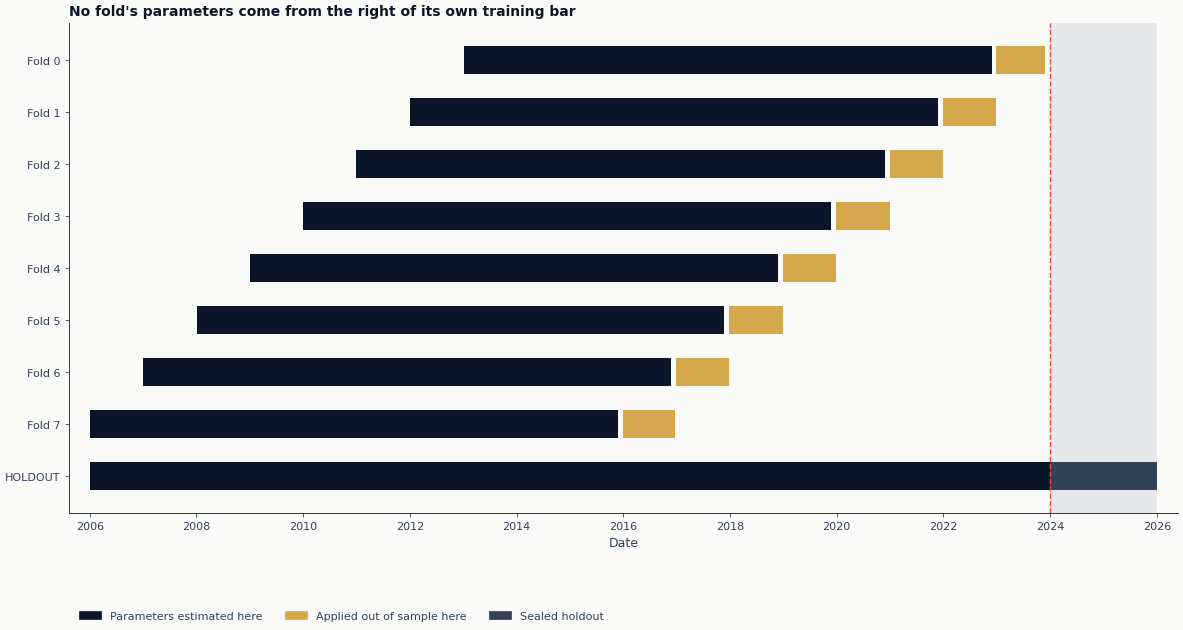

CV folds: 8, plus holdout fold (fold 8)
  Fold 0: train 2013-01-03 00:00:00..2022-11-28 00:00:00, val 2022-12-29 00:00:00..2023-11-29 00:00:00
  Fold 1: train 2011-12-30 00:00:00..2021-11-26 00:00:00, val 2021-12-29 00:00:00..2022-12-28 00:00:00
  Fold 2: train 2010-12-31 00:00:00..2020-11-25 00:00:00, val 2020-12-29 00:00:00..2021-12-28 00:00:00
  Fold 3: train 2009-12-31 00:00:00..2019-11-26 00:00:00, val 2019-12-30 00:00:00..2020-12-28 00:00:00
  Fold 4: train 2008-12-31 00:00:00..2018-11-26 00:00:00, val 2018-12-28 00:00:00..2019-12-27 00:00:00
  Fold 5: train 2008-01-02 00:00:00..2017-11-24 00:00:00, val 2017-12-27 00:00:00..2018-12-27 00:00:00
  Fold 6: train 2006-12-29 00:00:00..2016-11-23 00:00:00, val 2016-12-27 00:00:00..2017-12-26 00:00:00
  Fold 7: train 2006-01-03 00:00:00..2015-11-24 00:00:00, val 2015-12-28 00:00:00..2016-12-23 00:00:00
  HOLDOUT: train 2006-01-03 00:00:00..2024-01-01, val 2024-01-01..2025-12-31


In [5]:
fig_folds, ax = plt.subplots(figsize=(12, 0.5 * len(all_folds) + 2))

for f in all_folds:
    y = f["fold"]
    tr0, tr1 = pd.Timestamp(f["train_start"]), pd.Timestamp(f["train_end"])
    va0, va1 = pd.Timestamp(f["val_start"]), pd.Timestamp(f["val_end"])
    is_holdout = f["fold"] == len(cv_splits)
    ax.barh(y, tr1 - tr0, left=tr0, height=0.55, color=COLORS["blue"])
    ax.barh(
        y,
        va1 - va0,
        left=va0,
        height=0.55,
        color=COLORS["neutral"] if is_holdout else COLORS["amber"],
    )

ax.axvline(pd.Timestamp(holdout_start), color=COLORS["negative"], linestyle="--", linewidth=1.0)
ax.axvspan(
    pd.Timestamp(holdout_start),
    pd.Timestamp(holdout_end),
    color=COLORS["neutral"],
    alpha=0.10,
    linewidth=0,
)
ax.set_yticks([f["fold"] for f in all_folds])
ax.set_yticklabels(
    [("HOLDOUT" if f["fold"] == len(cv_splits) else f"Fold {f['fold']}") for f in all_folds]
)
ax.invert_yaxis()
ax.set_xlabel("Date")
handles = [
    plt.Rectangle((0, 0), 1, 1, color=COLORS["blue"]),
    plt.Rectangle((0, 0), 1, 1, color=COLORS["amber"]),
    plt.Rectangle((0, 0), 1, 1, color=COLORS["neutral"]),
]
# Outside the axes: every row is a full-width bar, so any in-axes placement
# lands the legend on top of one of them.
ax.legend(
    handles,
    ["Parameters estimated here", "Applied out of sample here", "Sealed holdout"],
    frameon=False,
    fontsize=8,
    loc="upper left",
    bbox_to_anchor=(0.0, -0.18),
    ncol=3,
)
# Keep the earliest training bar off the spine.
_span = pd.Timestamp(holdout_end) - pd.Timestamp(min(f["train_start"] for f in all_folds))
ax.set_xlim(
    pd.Timestamp(min(f["train_start"] for f in all_folds)) - _span * 0.02,
    pd.Timestamp(holdout_end) + _span * 0.02,
)
ax.set_title(
    "No fold's parameters come from the right of its own training bar",
    loc="left",
    color=COLORS["blue"],
    fontweight="semibold",
)
sns.despine()
fig_folds.tight_layout()
plt.show()

n_cv = len(cv_splits)
n_total = len(all_folds)
print(f"CV folds: {n_cv}, plus holdout fold (fold {n_cv})")
for fold in all_folds:
    label = "HOLDOUT" if fold["fold"] == n_cv else f"Fold {fold['fold']}"
    print(
        f"  {label}: train {fold['train_start']}..{fold['train_end']}, "
        f"val {fold['val_start']}..{fold['val_end']}"
    )

## Part 1: HMM Regime Detection

We fit a 2-state Gaussian HMM on SPY returns + volatility **per fold**.
The aggregate market drives regime classification; individual ETFs
inherit it.

### Why SPY Only

Using a single aggregate proxy (SPY) rather than per-asset HMMs:
- Avoids overfitting 100 independent HMMs
- Regime is a market-level phenomenon (risk-on/risk-off)
- All ETFs inherit the same regime state, ensuring cross-sectional consistency

In [6]:
spy_full = (
    prices.filter(pl.col("symbol") == "SPY")
    .sort("timestamp")
    .with_columns(
        log_ret=(pl.col("close").log().diff() * 100),
        vol_21d=(pl.col("close").log().diff().rolling_std(window_size=21) * 100 * np.sqrt(252)),
    )
    .drop_nulls()
)

print(
    f"SPY: {len(spy_full):,} observations ({spy_full['timestamp'].min()} to {spy_full['timestamp'].max()})"
)

SPY: 5,010 observations (2006-02-02 to 2025-12-31)


### K-Means-Seeded HMM Fitting

K-means clustering provides better initial emission parameters than random
initialization, reducing sensitivity to local optima.

In [7]:
def fit_hmm_kmeans_init(X: np.ndarray, n_states: int, random_state: int = 42) -> GaussianHMM:
    """Fit HMM with k-means-seeded initialization."""
    kmeans = KMeans(n_clusters=n_states, random_state=random_state, n_init=10)
    kmeans.fit(X)

    model = GaussianHMM(
        n_components=n_states,
        covariance_type="full",
        n_iter=200,
        random_state=random_state,
        init_params="st",  # Only init startprob and transmat
    )

    model.means_ = kmeans.cluster_centers_
    model.covars_ = np.array(
        [np.cov(X[kmeans.labels_ == k].T) + np.eye(X.shape[1]) * 1e-6 for k in range(n_states)]
    )

    model.fit(X)
    return model

### Label Switching Prevention

Sort states by variance (ascending) so State 0 is always "low volatility"
(calm) and State 1 is always "high volatility" (stressed).

In [8]:
def sort_states_by_variance(model: GaussianHMM) -> np.ndarray:
    """Sort HMM states by variance (ascending) for consistent labeling."""
    variances = np.array([np.trace(model.covars_[k]) for k in range(model.n_components)])
    return np.argsort(variances)  # Low vol first


def relabel_states(states: np.ndarray, probs: np.ndarray, order: np.ndarray) -> tuple:
    """Relabel states according to the given order."""
    inv_order = np.argsort(order)
    new_states = inv_order[states]
    new_probs = probs[:, order]
    return new_states, new_probs

### Filtered Probabilities (No Look-Ahead)

In production, we must use **filtered** probabilities $P(z_t | x_{1:t})$
which condition only on past and present observations. hmmlearn's
`predict_proba()` returns **smoothed** probabilities $P(z_t | x_{1:T})$
which use future data and would introduce look-ahead bias.

In [9]:
def compute_filtered_probs(model: GaussianHMM, X: np.ndarray) -> np.ndarray:
    """Compute filtered probabilities P(state_t | obs_{1:t}).

    Uses the forward algorithm, then normalizes.
    """
    framelogprob = model._compute_log_likelihood(X)

    n_samples = X.shape[0]
    n_components = model.n_components

    log_startprob = np.log(model.startprob_ + 1e-300)
    log_transmat = np.log(model.transmat_ + 1e-300)

    # Forward pass (log-domain for numerical stability)
    fwdlattice = np.zeros((n_samples, n_components))
    fwdlattice[0] = log_startprob + framelogprob[0]

    for t in range(1, n_samples):
        for j in range(n_components):
            fwdlattice[t, j] = framelogprob[t, j] + np.logaddexp.reduce(
                fwdlattice[t - 1] + log_transmat[:, j]
            )

    # Normalize to get probabilities
    log_normalizer = np.logaddexp.reduce(fwdlattice, axis=1, keepdims=True)
    filtered = np.exp(fwdlattice - log_normalizer)

    return filtered

### Derive Regime Features from Filtered Probabilities

From filtered probabilities, derive three feature types:
1. **regime_prob_stress**: Filtered probability of being in the high-vol state
2. **regime_transition**: Absolute change in stress probability (detects regime shifts)
3. **regime_duration**: Days since last regime change (persistence indicator)

In [10]:
def derive_regime_features(
    timestamps: pl.Series,
    filtered_probs: np.ndarray,
    order: np.ndarray,
) -> pl.DataFrame:
    """Derive regime features from HMM output for a single fold window.

    All three features derive from the FILTERED posterior (causal). The regime
    state that drives duration is the argmax of the filtered probability, NOT the
    Viterbi path (``model.predict``): Viterbi is the global MAP sequence over the
    whole window, so a validation-period state would depend on future
    observations and leak into ``regime_log_duration``.
    """
    filtered_sorted = filtered_probs[:, order]

    regime_prob_stress = filtered_sorted[:, 1]  # P(high-vol state), filtered

    # Causal regime state: argmax of the filtered 2-state posterior.
    states_sorted = (regime_prob_stress >= 0.5).astype(int)

    # Transition: absolute 1-day change in stress probability
    regime_transition = np.abs(np.diff(regime_prob_stress, prepend=regime_prob_stress[0]))

    # Duration: days since last regime change
    regime_duration = np.zeros(len(states_sorted))
    current_run = 0
    for i in range(len(states_sorted)):
        if i == 0 or states_sorted[i] != states_sorted[i - 1]:
            current_run = 1
        else:
            current_run += 1
        regime_duration[i] = current_run

    return pl.DataFrame(
        {
            "timestamp": timestamps,
            "regime_prob_stress": regime_prob_stress,
            "regime_transition": regime_transition,
            "regime_log_duration": np.log1p(regime_duration),
        }
    )

### Number of States

Two states, calm and stressed. The reader should note what is *not* here: no
full-sample fit. It is tempting to fit one HMM over the whole history to show
the regime overlay, and that picture is not the object this notebook produces
- it is fitted on data the per-fold models never see, and decoding it with
Viterbi conditions every date on the whole series including its future. The
overlay after the fold loop is drawn from the per-fold filtered probabilities
instead, which is what actually leaves this notebook.

In [11]:
N_STATES = 2

### Per-Fold HMM Fitting

For each fold, we fit the HMM on **training data only**, then apply the
forward algorithm to the full fold window (train_start through val_end)
for filtered probabilities. The model parameters $\theta$ are estimated
exclusively from training observations, eliminating parameter-level
look-ahead.

In [12]:
hmm_fold_results = []
hmm_fold_params = []

for fold in all_folds:
    fold_idx = fold["fold"]
    train_start, train_end = fold["train_start"], fold["train_end"]
    val_end = fold["val_end"]

    # Training data: fit HMM parameters
    spy_train = spy_full.filter(
        (pl.col("timestamp") >= pl.lit(train_start).cast(pl.Date))
        & (pl.col("timestamp") < pl.lit(train_end).cast(pl.Date))
    )
    X_train = spy_train.select(["log_ret", "vol_21d"]).to_numpy()

    if len(X_train) < 252:
        print(
            f"  Fold {fold_idx}: insufficient SPY training data ({len(X_train)} obs), skipping HMM"
        )
        continue

    # Fit HMM with multiple restarts on training data
    best_fold_model = None
    best_fold_ll = -np.inf
    for seed in range(N_RESTARTS):
        try:
            m = fit_hmm_kmeans_init(X_train, n_states=N_STATES, random_state=seed)
            ll = m.score(X_train)
            if ll > best_fold_ll:
                best_fold_ll = ll
                best_fold_model = m
        except Exception:
            continue

    if best_fold_model is None:
        print(f"  Fold {fold_idx}: HMM fitting failed")
        continue

    order = sort_states_by_variance(best_fold_model)

    # Full fold window (train_start through val_end) for filtered probs
    spy_fold = spy_full.filter(
        (pl.col("timestamp") >= pl.lit(train_start).cast(pl.Date))
        & (pl.col("timestamp") <= pl.lit(val_end).cast(pl.Date))
    )
    X_fold = spy_fold.select(["log_ret", "vol_21d"]).to_numpy()

    filtered = compute_filtered_probs(best_fold_model, X_fold)

    regime_df = derive_regime_features(spy_fold["timestamp"], filtered, order)
    regime_df = regime_df.with_columns(pl.lit(fold_idx).alias("fold"))

    hmm_fold_results.append(regime_df)

    # Keep the fitted parameters, in the sorted state order, so Section
    # "Fit Stability Across Folds" can draw what was estimated rather than what
    # the features happened to average to. `order[1]` is the high-variance state.
    _hi = int(order[1])
    _lo = int(order[0])
    hmm_fold_params.append(
        {
            "fold": fold_idx,
            "mean_ret_stress": float(best_fold_model.means_[_hi, 0]),
            "mean_vol_stress": float(best_fold_model.means_[_hi, 1]),
            "mean_vol_calm": float(best_fold_model.means_[_lo, 1]),
            "persist_stress": float(best_fold_model.transmat_[_hi, _hi]),
            "persist_calm": float(best_fold_model.transmat_[_lo, _lo]),
            "n_train": int(len(X_train)),
        }
    )

    print(
        f"  Fold {fold_idx}: HMM LL={best_fold_ll:.1f}, {len(regime_df)} dates, "
        f"stress={regime_df['regime_prob_stress'].mean():.3f}"
    )

hmm_features = (
    pl.concat(hmm_fold_results)
    if hmm_fold_results
    else pl.DataFrame(schema={"timestamp": pl.Date, "fold": pl.Int64})
)
n_hmm_folds = hmm_features["fold"].n_unique() if len(hmm_features) > 0 else 0
print(f"\nHMM features: {len(hmm_features):,} rows across {n_hmm_folds} folds")

  Fold 0: HMM LL=-10571.5, 2746 dates, stress=0.372


  Fold 1: HMM LL=-10217.1, 2767 dates, stress=0.338


  Fold 2: HMM LL=-10510.6, 2767 dates, stress=0.296


  Fold 3: HMM LL=-9765.9, 2767 dates, stress=0.391


  Fold 4: HMM LL=-10260.4, 2767 dates, stress=0.389


  Fold 5: HMM LL=-11320.2, 2767 dates, stress=0.285


  Fold 6: HMM LL=-11456.1, 2767 dates, stress=0.233


  Fold 7: HMM LL=-11235.6, 2744 dates, stress=0.251


  Fold 8: HMM LL=-20418.9, 5010 dates, stress=0.322

HMM features: 27,102 rows across 9 folds


### What the HMM Inferred, on Validation Dates

Each CV fold contributes only its **validation** window, and the shading is the
per-fold **filtered** probability of the stressed state - the same quantity
the saved feature carries. Read across the panel and every shaded band was
produced by a model that had not seen it.

The holdout fold is not drawn. Its features are computed and saved like every
other fold's, but reading them here at development time is exactly the use the
seal forbids, and the incremental evaluation below excludes it for the same
reason.

The bands are drawn where P(stress) exceeds one half. That threshold is a
reading aid for the figure; the emitted feature is the probability itself, and
nothing downstream thresholds it.

Validation dates plotted: 1,995 (2015-12-28 to 2023-11-29)


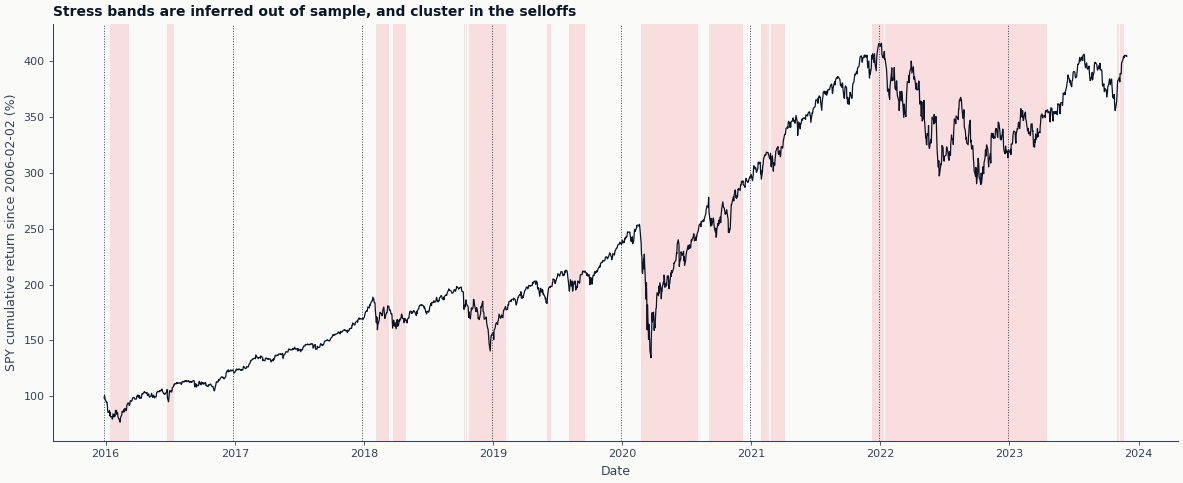

In [13]:
STRESS_SHADE_THRESHOLD = 0.5

val_regimes = pl.concat(
    [
        hmm_features.filter(
            (pl.col("fold") == f["fold"])
            & (pl.col("timestamp") >= pl.lit(f["val_start"]).cast(pl.Date))
            & (pl.col("timestamp") <= pl.lit(f["val_end"]).cast(pl.Date))
        )
        for f in cv_splits
    ]
).sort("timestamp")

spy_cum = spy_full.with_columns(cum_ret=(pl.col("close") / pl.col("close").first() - 1) * 100)
spy_val = spy_cum.join(val_regimes.select("timestamp"), on="timestamp", how="semi").sort(
    "timestamp"
)
print(
    f"Validation dates plotted: {len(val_regimes):,} "
    f"({val_regimes['timestamp'].min()} to {val_regimes['timestamp'].max()})"
)

fig_regime, ax = plt.subplots(figsize=(12, 5))
ax.plot(
    spy_val["timestamp"].to_numpy(),
    spy_val["cum_ret"].to_numpy(),
    linewidth=0.9,
    color=COLORS["blue"],
)

# Shade contiguous runs above the threshold.
_dates = val_regimes["timestamp"].to_numpy()
_stress = (val_regimes["regime_prob_stress"] > STRESS_SHADE_THRESHOLD).to_numpy()
_in_run, _start = False, None
for _i in range(len(_stress)):
    if _stress[_i] and not _in_run:
        _start, _in_run = _dates[_i], True
    elif not _stress[_i] and _in_run:
        ax.axvspan(_start, _dates[_i], alpha=0.15, color=COLORS["negative"], linewidth=0)
        _in_run = False
if _in_run:
    ax.axvspan(_start, _dates[-1], alpha=0.15, color=COLORS["negative"], linewidth=0)

# Fold boundaries: one rule per validation window start.
for f in cv_splits:
    ax.axvline(pd.Timestamp(f["val_start"]), color=COLORS["neutral"], linestyle=":", linewidth=0.7)

ax.set_xlabel("Date")
# The curve is the full-history cumulative return sampled at validation dates, so
# the baseline is the start of the price series and not the start of the plot.
ax.set_ylabel(f"SPY cumulative return since {spy_cum['timestamp'].min()} (%)")
ax.set_title(
    "Stress bands are inferred out of sample, and cluster in the selloffs",
    loc="left",
    color=COLORS["blue"],
    fontweight="semibold",
)
sns.despine()
fig_regime.tight_layout()
plt.show()

## Part 2: Fractional Differencing (Per Fold)

Fractional differencing preserves long-range memory while achieving
stationarity. We apply fixed $d$ values by asset class to 10 reference
ETFs spanning all major asset classes in our universe.

**Why fixed $d$?** Using pre-specified $d$ values avoids parameter estimation
lookahead entirely -- no data-dependent optimization, so the transform is
purely mechanical. We still compute per fold so each fold window gets a
clean series starting from its own `train_start`.

The mapping is declared in the next cell and printed from there, so the values
a reader sees are the ones the transform used.

In [14]:
REFERENCE_ETFS = {
    "SPY": 0.4,  # US large-cap equities
    "QQQ": 0.4,  # US tech equities
    "IWM": 0.4,  # US small-cap equities
    "EFA": 0.4,  # International developed
    "EEM": 0.4,  # Emerging markets
    "TLT": 0.5,  # Long-term treasuries
    "GLD": 0.4,  # Gold
    "VNQ": 0.4,  # Real estate
    "HYG": 0.5,  # High yield bonds
    "LQD": 0.5,  # Investment grade bonds
}

print("Fractional differencing order by reference ETF:")
for _sym, _d in REFERENCE_ETFS.items():
    print(f"  {_sym:<5s} d={_d}")

Fractional differencing order by reference ETF:
  SPY   d=0.4
  QQQ   d=0.4
  IWM   d=0.4
  EFA   d=0.4
  EEM   d=0.4
  TLT   d=0.5
  GLD   d=0.4
  VNQ   d=0.4
  HYG   d=0.5
  LQD   d=0.5


### Per-Fold FFD Application

For each fold, apply fractional differencing to the fold window
(train_start through val_end). The FFD filter uses a fixed-width window
of historical weights, so it only needs a warmup period at the start --
no fitting is involved. Computing per fold ensures the warmup loss
does not leak information across fold boundaries.

In [15]:
ffd_fold_results = []

for fold in all_folds:
    fold_idx = fold["fold"]
    train_start = fold["train_start"]
    val_end = fold["val_end"]

    fold_frames = []
    for symbol, d in REFERENCE_ETFS.items():
        etf = (
            prices.filter(
                (pl.col("symbol") == symbol)
                & (pl.col("timestamp") >= pl.lit(train_start).cast(pl.Date))
                & (pl.col("timestamp") <= pl.lit(val_end).cast(pl.Date))
            )
            .sort("timestamp")
            .select(["timestamp", "close"])
        )

        if len(etf) == 0:
            continue

        log_close = etf["close"].log()
        ffd_series = ffdiff(log_close, d=d)

        ffd_df = pl.DataFrame(
            {
                "timestamp": etf["timestamp"],
                f"ffd_{symbol.lower()}": ffd_series,
            }
        ).drop_nulls()

        fold_frames.append(ffd_df)

    if fold_frames:
        ffd_fold = fold_frames[0]
        for df in fold_frames[1:]:
            ffd_fold = ffd_fold.join(df, on="timestamp", how="outer_coalesce")
        ffd_fold = ffd_fold.sort("timestamp").with_columns(pl.lit(fold_idx).alias("fold"))
        ffd_fold_results.append(ffd_fold)
        ffd_cols = [c for c in ffd_fold.columns if c.startswith("ffd_")]
        print(f"  Fold {fold_idx}: FFD {len(ffd_cols)} series, {len(ffd_fold):,} dates")
    else:
        print(f"  Fold {fold_idx}: no FFD series produced (no qualifying ETFs)")

ffd_features = pl.concat(ffd_fold_results) if ffd_fold_results else pl.DataFrame()
ffd_col_names = [c for c in ffd_features.columns if c.startswith("ffd_")]
print(f"\nFFD features: {len(ffd_col_names)} series, {len(ffd_features):,} rows across folds")

  Fold 0: FFD 10 series, 2,746 dates


  Fold 1: FFD 10 series, 2,767 dates


  Fold 2: FFD 10 series, 2,767 dates


  Fold 3: FFD 10 series, 2,767 dates


  Fold 4: FFD 10 series, 2,767 dates


  Fold 5: FFD 10 series, 2,767 dates


  Fold 6: FFD 10 series, 2,767 dates


  Fold 7: FFD 10 series, 2,765 dates


  Fold 8: FFD 10 series, 5,031 dates

FFD features: 10 series, 27,144 rows across folds


## Part 3: Per-ETF GARCH(1,1) (Per Fold)

For each fold, fit GARCH(1,1) on each ETF's **training returns**, then
use `model.fix(params)` to run the variance recursion on the full fold
window (train through val_end) without re-estimating parameters. This
is the **fit-then-filter** paradigm: parameters come from training only,
but conditional volatility is computed for every date in the window.

The `fix()` method applies frozen parameters to a new data series,
producing a causal conditional volatility path $\sigma_t$ that depends
only on past returns given the frozen parameters.

In [16]:
all_symbols = sorted(prices["symbol"].unique().to_list())
if MAX_SYMBOLS > 0:
    all_symbols = all_symbols[:MAX_SYMBOLS]

print(f"Fitting GARCH(1,1) on {len(all_symbols)} ETFs across {len(all_folds)} folds...")

Fitting GARCH(1,1) on 100 ETFs across 9 folds...


In [17]:
def fit_garch_fold(
    prices_df: pl.DataFrame,
    symbols: list[str],
    fold: dict,
    min_obs: int,
) -> tuple[pl.DataFrame, pl.DataFrame]:
    """Fit GARCH(1,1) per symbol for one fold.

    Parameters
    ----------
    prices_df : pl.DataFrame
        Full prices panel with timestamp, symbol, close columns.
    symbols : list[str]
        Symbols to fit.
    fold : dict
        Fold dict with train_start, train_end, val_end keys.
    min_obs : int
        Minimum training observations for GARCH fit.

    Returns
    -------
    pl.DataFrame
        Conditional volatility for the full fold window with fold column.
    """
    fold_idx = fold["fold"]
    train_start = fold["train_start"]
    train_end = fold["train_end"]
    val_end = fold["val_end"]

    results = []
    param_rows = []
    n_success = 0
    n_fail = 0

    for sym in symbols:
        # Get full fold window data (train_start through val_end)
        sym_data = (
            prices_df.filter(
                (pl.col("symbol") == sym)
                & (pl.col("timestamp") >= pl.lit(train_start).cast(pl.Date))
                & (pl.col("timestamp") <= pl.lit(val_end).cast(pl.Date))
            )
            .sort("timestamp")
            .with_columns(ret=pl.col("close").pct_change())
            .drop_nulls(subset=["ret"])
        )

        # Training returns only
        train_data = sym_data.filter(pl.col("timestamp") < pl.lit(train_end).cast(pl.Date))

        if len(train_data) < min_obs:
            n_fail += 1
            continue

        train_returns_pct = (train_data["ret"] * 100).to_numpy()

        try:
            # Fit on training data
            train_model = arch_model(
                train_returns_pct,
                mean="Constant",
                vol="GARCH",
                p=1,
                q=1,
                dist="Normal",
            )
            train_result = train_model.fit(disp="off", show_warning=False)

            # Apply frozen parameters to full fold window
            full_returns_pct = (sym_data["ret"] * 100).to_numpy()
            full_model = arch_model(
                full_returns_pct,
                mean="Constant",
                vol="GARCH",
                p=1,
                q=1,
                dist="Normal",
            )
            filtered = full_model.fix(train_result.params)

            # Keep the frozen training parameters: persistence (alpha+beta) is the
            # number that says whether this fold's fit is near-integrated.
            _pr = train_result.params
            param_rows.append(
                {
                    "symbol": sym,
                    "omega": float(_pr.get("omega", np.nan)),
                    "alpha": float(_pr.get("alpha[1]", np.nan)),
                    "beta": float(_pr.get("beta[1]", np.nan)),
                }
            )

            # Annualized conditional vol (input is in % daily)
            cond_vol_ann = filtered.conditional_volatility * np.sqrt(252) / 100

            sym_result = pl.DataFrame(
                {
                    "timestamp": sym_data["timestamp"].to_list(),
                    "symbol": [sym] * len(sym_data),
                    "garch_cond_vol": cond_vol_ann,
                    "fold": [fold_idx] * len(sym_data),
                }
            ).drop_nulls()

            if len(sym_result) > 0:
                results.append(sym_result)
                n_success += 1
        except Exception:
            n_fail += 1

    print(f"  Fold {fold_idx} GARCH: {n_success}/{len(symbols)} fitted, {n_fail} failed/skipped")
    params = (
        pl.DataFrame(param_rows).with_columns(pl.lit(fold_idx).alias("fold"))
        if param_rows
        else pl.DataFrame()
    )
    return (pl.concat(results) if results else pl.DataFrame()), params

In [18]:
garch_fold_results = []
garch_fold_params = []

for fold in all_folds:
    garch_fold, garch_params = fit_garch_fold(prices, all_symbols, fold, GARCH_MIN_OBS)
    if len(garch_fold) > 0:
        garch_fold_results.append(garch_fold)
    if len(garch_params) > 0:
        garch_fold_params.append(garch_params)

garch_df = pl.concat(garch_fold_results) if garch_fold_results else pl.DataFrame()
garch_param_df = pl.concat(garch_fold_params) if garch_fold_params else pl.DataFrame()
garch_cols = ["garch_cond_vol"]

if len(garch_df) > 0:
    n_syms = garch_df["symbol"].n_unique()
    print(
        f"\nGARCH features: {len(garch_df):,} rows, {n_syms} assets, {garch_df['fold'].n_unique()} folds"
    )
    print(
        f"  Conditional vol: mean={garch_df['garch_cond_vol'].mean():.3f}, "
        f"std={garch_df['garch_cond_vol'].std():.3f}"
    )

  Fold 0 GARCH: 100/100 fitted, 0 failed/skipped


  Fold 1 GARCH: 100/100 fitted, 0 failed/skipped


  Fold 2 GARCH: 100/100 fitted, 0 failed/skipped


  Fold 3 GARCH: 99/100 fitted, 1 failed/skipped


  Fold 4 GARCH: 99/100 fitted, 1 failed/skipped


  Fold 5 GARCH: 99/100 fitted, 1 failed/skipped


  Fold 6 GARCH: 98/100 fitted, 2 failed/skipped


  Fold 7 GARCH: 98/100 fitted, 2 failed/skipped


  Fold 8 GARCH: 100/100 fitted, 0 failed/skipped

GARCH features: 2,565,067 rows, 100 assets, 9 folds
  Conditional vol: mean=0.180, std=0.127


## Part 4: Combine and Broadcast to Per-Fold Panel

HMM regime features and FFD features are date-level (one value per day
shared by all ETFs). GARCH features are per-asset. For each fold, we
broadcast date-level features to all symbols and join with per-asset
GARCH features, producing a `(fold, timestamp, symbol)` panel.

In [19]:
fold_panels = []

for fold in all_folds:
    fold_idx = fold["fold"]
    train_start = fold["train_start"]
    val_end = fold["val_end"]

    # Get panel skeleton for this fold's date range
    fold_skeleton = (
        prices.filter(
            (pl.col("timestamp") >= pl.lit(train_start).cast(pl.Date))
            & (pl.col("timestamp") <= pl.lit(val_end).cast(pl.Date))
        )
        .select(["timestamp", "symbol"])
        .unique()
        .sort(["timestamp", "symbol"])
        .with_columns(pl.lit(fold_idx).alias("fold"))
    )

    # Get date-level features for this fold
    fold_hmm = (
        hmm_features.filter(pl.col("fold") == fold_idx).drop("fold")
        if len(hmm_features) > 0
        else pl.DataFrame()
    )
    fold_ffd = (
        ffd_features.filter(pl.col("fold") == fold_idx).drop("fold")
        if len(ffd_features) > 0
        else pl.DataFrame()
    )

    # Combine date-level features
    if len(fold_hmm) > 0 and len(fold_ffd) > 0:
        date_level = fold_hmm.join(fold_ffd, on="timestamp", how="outer_coalesce")
    elif len(fold_hmm) > 0:
        date_level = fold_hmm
    elif len(fold_ffd) > 0:
        date_level = fold_ffd
    else:
        date_level = pl.DataFrame()

    # Broadcast date-level features to all assets
    if len(date_level) > 0:
        panel = fold_skeleton.join(date_level, on="timestamp", how="left")
    else:
        panel = fold_skeleton

    # Join per-asset GARCH features
    if len(garch_df) > 0:
        fold_garch = garch_df.filter(pl.col("fold") == fold_idx).drop("fold")
        panel = panel.join(fold_garch, on=["timestamp", "symbol"], how="left")

    fold_panels.append(panel)

temporal = pl.concat(fold_panels).sort(["fold", "timestamp", "symbol"])

temporal_cols = [c for c in temporal.columns if c not in ("timestamp", "symbol", "fold")]
print(f"Combined model-based features: {len(temporal_cols)} columns, {len(temporal):,} rows")
print(f"  Assets: {temporal['symbol'].n_unique()}, Folds: {temporal['fold'].n_unique()}")

Combined model-based features: 14 columns, 2,567,981 rows
  Assets: 100, Folds: 9


### Quality Check

Verify that temporal features have reasonable coverage and distributions.

In [20]:
for col in temporal_cols:
    valid = temporal[col].drop_nulls().len()
    total = len(temporal)
    mean = temporal[col].drop_nulls().mean()
    std = temporal[col].drop_nulls().std()
    print(f"  {col:30s}: {valid:,}/{total:,} valid, mean={mean:.4f}, std={std:.4f}")

  regime_prob_stress            : 2,565,503/2,567,981 valid, mean=0.3164, std=0.4508
  regime_transition             : 2,565,503/2,567,981 valid, mean=0.0203, std=0.0865
  regime_log_duration           : 2,565,503/2,567,981 valid, mean=3.9228, std=1.3338
  ffd_spy                       : 2,567,981/2,567,981 valid, mean=0.2482, std=0.1382
  ffd_qqq                       : 2,567,981/2,567,981 valid, mean=0.2257, std=0.1122
  ffd_iwm                       : 2,567,981/2,567,981 valid, mean=0.2209, std=0.1248
  ffd_efa                       : 2,567,981/2,567,981 valid, mean=0.1818, std=0.1131
  ffd_eem                       : 2,567,981/2,567,981 valid, mean=0.1646, std=0.1069
  ffd_tlt                       : 2,567,981/2,567,981 valid, mean=0.1059, std=0.1015
  ffd_gld                       : 2,567,981/2,567,981 valid, mean=0.2300, std=0.1466
  ffd_vnq                       : 2,567,981/2,567,981 valid, mean=0.1855, std=0.1050
  ffd_hyg                       : 2,519,712/2,567,981 valid, mean

### Fit Stability Across Folds

The training windows overlap heavily, so the fitted parameters should move
slowly as the window rolls. Two things are worth separating, and the old
version of this section conflated them: the **features** a fold produced, and
the **parameters** that produced them. Feature means move with the market the
fold happens to cover; parameters moving is a statement about the model.

A parameter that is flat across folds says per-fold refitting bought nothing.
One that swings is a warning about the feature that depends on it.

In [21]:
print("\nPer-fold feature means:")
fold_summary = (
    temporal.group_by("fold")
    .agg([pl.col(c).mean().alias(f"mean_{c}") for c in temporal_cols])
    .sort("fold")
)
print(fold_summary)


Per-fold feature means:


shape: (9, 15)
┌──────┬────────────┬────────────┬────────────┬───┬────────────┬───────────┬───────────┬───────────┐
│ fold ┆ mean_regim ┆ mean_regim ┆ mean_regim ┆ … ┆ mean_ffd_v ┆ mean_ffd_ ┆ mean_ffd_ ┆ mean_garc │
│ ---  ┆ e_prob_str ┆ e_transiti ┆ e_log_dura ┆   ┆ nq         ┆ hyg       ┆ lqd       ┆ h_cond_vo │
│ i32  ┆ ess        ┆ on         ┆ tion       ┆   ┆ ---        ┆ ---       ┆ ---       ┆ l         │
│      ┆ ---        ┆ ---        ┆ ---        ┆   ┆ f64        ┆ f64       ┆ f64       ┆ ---       │
│      ┆ f64        ┆ f64        ┆ f64        ┆   ┆            ┆           ┆           ┆ f64       │
╞══════╪════════════╪════════════╪════════════╪═══╪════════════╪═══════════╪═══════════╪═══════════╡
│ 0    ┆ 0.373789   ┆ 0.020577   ┆ 3.735992   ┆ … ┆ 0.203968   ┆ 0.099847  ┆ 0.111027  ┆ 0.170289  │
│ 1    ┆ 0.340508   ┆ 0.021919   ┆ 3.679342   ┆ … ┆ 0.200837   ┆ 0.09831   ┆ 0.109863  ┆ 0.166814  │
│ 2    ┆ 0.294797   ┆ 0.023507   ┆ 3.597405   ┆ … ┆ 0.197179   ┆ 0.097369  ┆

In [22]:
hmm_param_df = pl.DataFrame(hmm_fold_params).sort("fold")
print("\nPer-fold HMM parameters (states ordered by variance):")
print(hmm_param_df)

if len(garch_param_df):
    garch_param_summary = (
        garch_param_df.with_columns(persistence=pl.col("alpha") + pl.col("beta"))
        .group_by("fold")
        .agg(
            pl.col("alpha").median().alias("alpha_median"),
            pl.col("beta").median().alias("beta_median"),
            pl.col("persistence").median().alias("persistence_median"),
            pl.len().alias("n_fits"),
        )
        .sort("fold")
    )
    print("\nPer-fold GARCH parameters (median across ETFs):")
    print(garch_param_summary)


Per-fold HMM parameters (states ordered by variance):
shape: (9, 7)
┌──────┬────────────────┬────────────────┬───────────────┬────────────────┬──────────────┬─────────┐
│ fold ┆ mean_ret_stres ┆ mean_vol_stres ┆ mean_vol_calm ┆ persist_stress ┆ persist_calm ┆ n_train │
│ ---  ┆ s              ┆ s              ┆ ---           ┆ ---            ┆ ---          ┆ ---     │
│ i64  ┆ ---            ┆ ---            ┆ f64           ┆ f64            ┆ f64          ┆ i64     │
│      ┆ f64            ┆ f64            ┆               ┆                ┆              ┆         │
╞══════╪════════════════╪════════════════╪═══════════════╪════════════════╪══════════════╪═════════╡
│ 0    ┆ -0.002851      ┆ 23.252215      ┆ 9.465785      ┆ 0.982089       ┆ 0.989484     ┆ 2493    │
│ 1    ┆ 0.02224        ┆ 23.365993      ┆ 9.810382      ┆ 0.974773       ┆ 0.991741     ┆ 2493    │
│ 2    ┆ 0.013758       ┆ 24.598774      ┆ 9.76142       ┆ 0.979601       ┆ 0.990882     ┆ 2493    │
│ 3    ┆ 0.021692     

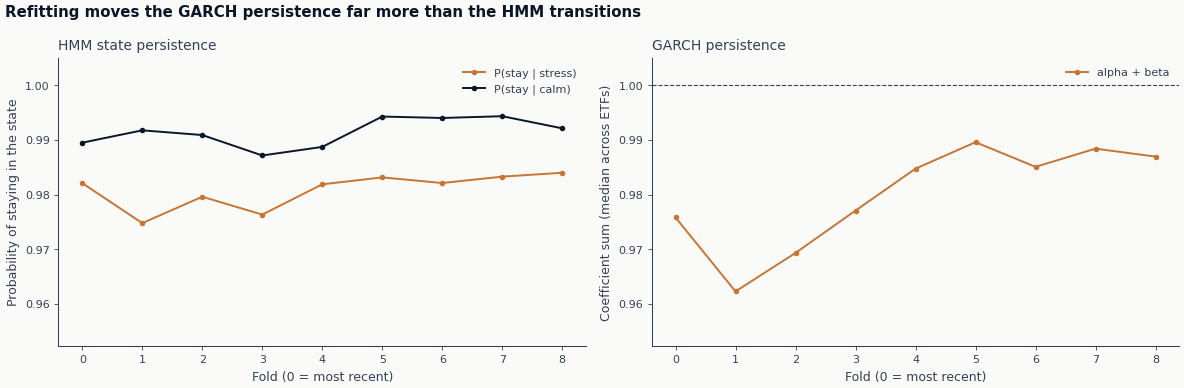

In [23]:
fig_stab, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(12, 4))

ax_l.plot(
    hmm_param_df["fold"],
    hmm_param_df["persist_stress"],
    marker="o",
    color=COLORS["copper"],
    label="P(stay | stress)",
)
ax_l.plot(
    hmm_param_df["fold"],
    hmm_param_df["persist_calm"],
    marker="o",
    color=COLORS["blue"],
    label="P(stay | calm)",
)
ax_l.set_xlabel("Fold (0 = most recent)")
ax_l.set_ylabel("Probability of staying in the state")
ax_l.legend(frameon=False, fontsize=8)
ax_l.set_title("HMM state persistence", loc="left", fontsize=10)

if len(garch_param_df):
    ax_r.plot(
        garch_param_summary["fold"],
        garch_param_summary["persistence_median"],
        marker="o",
        color=COLORS["copper"],
        label="alpha + beta",
    )
    ax_r.axhline(1.0, color=COLORS["neutral"], linestyle="--", linewidth=0.8)
    ax_r.set_ylabel("Coefficient sum (median across ETFs)")
    ax_r.legend(frameon=False, fontsize=8)
ax_r.set_xlabel("Fold (0 = most recent)")
ax_r.set_title("GARCH persistence", loc="left", fontsize=10)

# Both panels carry a persistence on [0, 1], so they share limits. Letting each
# autoscale is what makes a flat line and a moving one look equally dramatic,
# and the claim in the suptitle is a comparison between the two panels.
_stab_lo = min(
    float(hmm_param_df["persist_stress"].min()),
    float(hmm_param_df["persist_calm"].min()),
    float(garch_param_summary["persistence_median"].min()) if len(garch_param_df) else 1.0,
)
for _ax in (ax_l, ax_r):
    _ax.set_ylim(_stab_lo - 0.01, 1.005)

fig_stab.suptitle(
    "Refitting moves the GARCH persistence far more than the HMM transitions",
    x=0.01,
    ha="left",
    color=COLORS["blue"],
    fontweight="semibold",
)
sns.despine()
fig_stab.tight_layout()
plt.show()

## Save Artifacts

In [24]:
FEATURES_DIR = CASE_DIR / "features"

FEATURES_DIR.mkdir(parents=True, exist_ok=True)
temporal.write_parquet(FEATURES_DIR / "model_based.parquet")
print(
    f"Saved: features/model_based.parquet "
    f"({len(temporal):,} rows, {len(temporal_cols)} features + fold column)"
)

Saved: features/model_based.parquet (2,567,981 rows, 14 features + fold column)


## Incremental Evaluation

Evaluate feature quality using **validation-period data only** from each
**CV** fold. We compute cross-sectional Spearman IC for per-asset features and
time-series IC for date-level features. The holdout fold is deliberately
EXCLUDED from this development-time readout -- its features are saved for the
final out-of-sample evaluation, but letting the holdout inform feature-quality
expectations here would break the seal (mirrors the scoping in 02/03).

In [25]:
labels = pl.read_parquet(CASE_DIR / "labels" / f"{PRIMARY_LABEL}.parquet")
label_col = PRIMARY_LABEL

# Only evaluate on validation periods of the CV folds (exclude the holdout fold)
val_rows = []
for fold in cv_splits:
    fold_idx = fold["fold"]
    val_start = fold["val_start"]
    val_end = fold["val_end"]
    fold_val = temporal.filter(
        (pl.col("fold") == fold_idx)
        & (pl.col("timestamp") >= pl.lit(val_start).cast(pl.Date))
        & (pl.col("timestamp") <= pl.lit(val_end).cast(pl.Date))
    )
    val_rows.append(fold_val)

val_temporal = pl.concat(val_rows) if val_rows else temporal

eval_df = val_temporal.join(labels, on=["timestamp", "symbol"], how="inner").drop_nulls(
    subset=[label_col]
)
print(
    f"Evaluation panel (val periods only): {len(eval_df):,} rows, {eval_df['symbol'].n_unique()} assets"
)

Evaluation panel (val periods only): 198,877 rows, 100 assets


### Cross-Sectional IC for Per-Asset Features

In [26]:
temporal_ic = {}

# Per-asset features: cross-sectional IC (rank correlation per date)
per_asset_features = [c for c in temporal_cols if c in garch_cols]
date_level_features = [c for c in temporal_cols if c not in garch_cols]

for feat in per_asset_features:
    ic_series = (
        eval_df.filter(pl.col(feat).is_not_null())
        .with_columns(
            pl.col(feat).rank(method="average").over("timestamp").alias("_feat_rank"),
            pl.col(label_col).rank(method="average").over("timestamp").alias("_label_rank"),
        )
        .group_by("timestamp")
        .agg(pl.corr("_feat_rank", "_label_rank").alias("ic"))
        .sort("timestamp")
        .drop_nulls("ic")
    )
    if len(ic_series) > 50:
        # Overlapping daily ICs: the horizon sets the HAC lag.
        stats = compute_ic_hac_stats(ic_series, ic_col="ic", label_horizon=LABEL_HORIZON_DAYS)
        temporal_ic[feat] = {
            "ic": stats["mean_ic"],
            "t_stat": stats["t_stat"],
            "naive_t_stat": stats["naive_t_stat"],
            "p_value": stats["p_value"],
            "bootstrap_std": stats["hac_se"],
        }

### Time-Series IC for Date-Level Features

Date-level features (HMM, FFD) are identical across symbols on each date,
so cross-sectional IC is zero by construction. We evaluate them via
time-series correlation with the cross-sectional average return.

In [27]:
avg_ret = (
    eval_df.group_by("timestamp")
    .agg(pl.col(label_col).mean().alias("avg_fwd_ret"))
    .sort("timestamp")
)

date_features = (
    val_temporal.select(["timestamp"] + date_level_features)
    .unique(subset=["timestamp"])
    .sort("timestamp")
)
eval_ts = date_features.join(avg_ret, on="timestamp", how="inner").drop_nulls()

# `robust_ic` resamples through the stationary bootstrap, and the library draws
# from numpy's legacy global generator without seeding it
# (`ml4t/diagnostic/evaluation/stats/bootstrap.py`, `np.random.randint` and
# `np.random.geometric`). Unseeded, the p-values move from run to run and the
# Benjamini-Hochberg count below moves with them - two consecutive production runs
# of this notebook retained 7 and then 8 of the same 14 features, on identical ICs.
# The seed is what makes the committed number the one a reader reproduces. The
# per-asset HAC statistics are deterministic and unaffected.
BOOTSTRAP_SEED = 20260805
np.random.seed(BOOTSTRAP_SEED)

for feat in date_level_features:
    x = eval_ts[feat].to_numpy()
    y = eval_ts["avg_fwd_ret"].to_numpy()
    valid = ~(np.isnan(x) | np.isnan(y))
    if valid.sum() < 50:
        continue
    result = robust_ic(x[valid], y[valid], return_details=True)
    temporal_ic[feat] = result

### Multiplicity Control

Every feature above was screened against the same label on the same validation
rows, so the per-feature p-values cannot be read one at a time. Benjamini-Hochberg
is applied across the whole set, and the retained count is what the figure below
reports. Both IC types now carry a dependence-aware standard error: HAC for the
per-asset series, stationary bootstrap for the date-level ones.

In [28]:
temporal_eval = pl.DataFrame(
    [
        {
            "feature": feat,
            "ic": stats["ic"],
            "t_stat": stats.get("t_stat", 0.0),
            "p_value": stats.get("p_value"),
            "bootstrap_se": stats.get("bootstrap_std", stats.get("bootstrap_se", 0.0)),
        }
        for feat, stats in temporal_ic.items()
    ]
).sort("ic", descending=True)

_p = temporal_eval["p_value"].to_list()
if temporal_eval.height and all(v is not None for v in _p):
    _fdr = benjamini_hochberg_fdr(_p, alpha=0.05, return_details=True)
    temporal_eval = temporal_eval.with_columns(fdr_significant=pl.Series(_fdr["rejected"].tolist()))
else:
    temporal_eval = temporal_eval.with_columns(fdr_significant=pl.lit(False, dtype=pl.Boolean))
n_fdr_sig = int(temporal_eval.filter(pl.col("fdr_significant")).height)

print("\nModel-Based Feature Evaluation (validation periods only):")
print(temporal_eval)
print(f"Retained by Benjamini-Hochberg at 5%: {n_fdr_sig} of {temporal_eval.height}")


Model-Based Feature Evaluation (validation periods only):
shape: (14, 6)
┌────────────────────┬───────────┬───────────┬──────────┬──────────────┬─────────────────┐
│ feature            ┆ ic        ┆ t_stat    ┆ p_value  ┆ bootstrap_se ┆ fdr_significant │
│ ---                ┆ ---       ┆ ---       ┆ ---      ┆ ---          ┆ ---             │
│ str                ┆ f64       ┆ f64       ┆ f64      ┆ f64          ┆ bool            │
╞════════════════════╪═══════════╪═══════════╪══════════╪══════════════╪═════════════════╡
│ regime_prob_stress ┆ 0.20162   ┆ 2.501836  ┆ 0.008    ┆ 0.080589     ┆ true            │
│ ffd_tlt            ┆ 0.189477  ┆ 2.46541   ┆ 0.003    ┆ 0.076854     ┆ true            │
│ ffd_lqd            ┆ 0.139792  ┆ 1.86723   ┆ 0.035    ┆ 0.074866     ┆ false           │
│ ffd_gld            ┆ 0.069414  ┆ 0.802223  ┆ 0.323    ┆ 0.086527     ┆ false           │
│ garch_cond_vol     ┆ 0.068744  ┆ 2.525028  ┆ 0.011646 ┆ 0.027225     ┆ true            │
│ …             

The bars carry no error bars because the two IC types have different
uncertainty scales - stationary-bootstrap SE for the date-level features, HAC SE
for the per-asset ones - so a shared error-bar axis would mislead. The exact
t-statistics and p-values are in the table above.

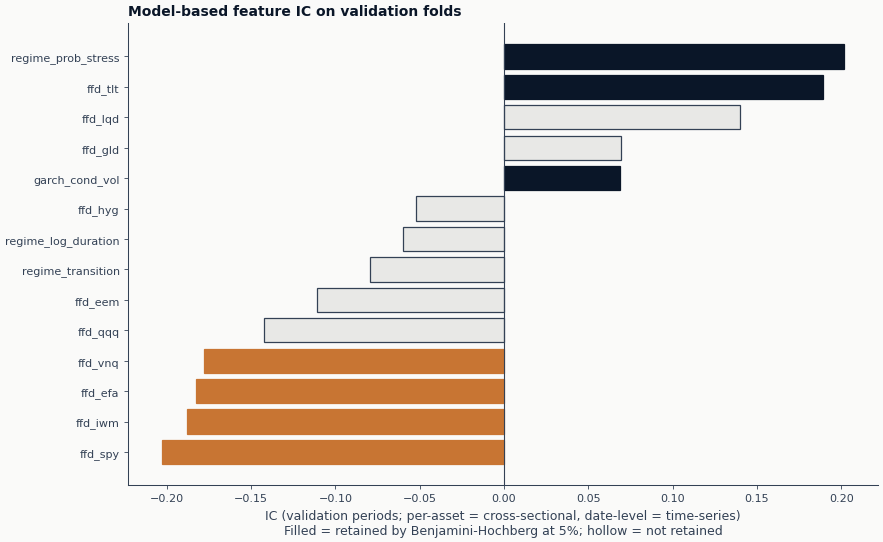

In [29]:
te = temporal_eval.sort("ic")
feats = te["feature"].to_list()
ics = te["ic"].to_numpy()
# Retained vs not is a semantic distinction, so it needs contrast in lightness
# rather than shade: the palette's dark end (blue, blue_light, slate, neutral)
# is four navies that do not separate when read as bars. Unretained features are
# drawn hollow.
bar_colors = [
    (COLORS["blue"] if row["ic"] >= 0 else COLORS["copper"])
    if row["fdr_significant"]
    else COLORS["silver_muted"]
    for row in te.to_dicts()
]
bar_edges = [
    (COLORS["blue"] if row["ic"] >= 0 else COLORS["copper"])
    if row["fdr_significant"]
    else COLORS["neutral"]
    for row in te.to_dicts()
]

fig_ic, ax = plt.subplots(figsize=(9, max(3.0, 0.4 * len(feats))))
ax.barh(feats, ics, color=bar_colors, edgecolor=bar_edges, linewidth=0.9)
ax.axvline(0, color=COLORS["neutral"], linewidth=0.8)
ax.set_xlabel(
    "IC (validation periods; per-asset = cross-sectional, date-level = time-series)"
    "\nFilled = retained by Benjamini-Hochberg at 5%; hollow = not retained"
)
ax.set_title(
    "No model-based feature is retained after multiplicity control"
    if n_fdr_sig == 0
    else "Model-based feature IC on validation folds",
    loc="left",
    color=COLORS["blue"],
    fontweight="semibold",
)
sns.despine()
fig_ic.tight_layout()
plt.show()

**Reading the two IC types.** They answer different questions and are not
comparable to each other. `garch_cond_vol` varies across ETFs on a date, so its
IC asks whether the cross-section of predicted volatility orders the
cross-section of forward returns - and the sign of that ordering is whatever
the table above reports, in either direction. The HMM and FFD features are
identical across ETFs on a date, so a cross-sectional IC on them is zero by
construction; theirs is a time-series correlation against the average forward
return, which is a statement about market timing rather than about ranking.

Because every feature is computed per fold from training-only parameters, these
are out-of-sample estimates rather than in-sample fit. They are still a screen
and not a decision: nothing here drops a feature, and the comparison against the
stage-03 financial features belongs to `05_evaluation`.

## Key Takeaways

1. **Per-fold fitting eliminates parameter look-ahead**: HMM and GARCH
   parameters are estimated on each fold's training window only.
   The `fold` column in the output lets downstream models use the
   correct features for each CV fold.
2. **HMM on aggregate market**: 2-state Gaussian HMM on SPY captures
   market-wide risk-on/risk-off regimes. All ETFs inherit the same state.
3. **Filtered probabilities**: Forward algorithm only -- smoothed probs
   use future data and would introduce observation-level look-ahead bias.
4. **Label switching prevention**: States sorted by variance ensures
   State 0 = calm, State 1 = stressed across all folds.
5. **GARCH fit-then-filter**: `model.fix(params)` applies frozen training
   parameters to the full fold window, producing causal conditional
   volatility without re-estimation.
6. **Fractional differencing**: A fixed $d$ per asset class requires no
   fitting, so there is no estimation lookahead to exclude; it is still
   computed per fold window for clean warmup handling. The orders used are
   printed in Part 2.
7. **Per-ETF GARCH**: Conditional volatility provides asset-specific risk
   dynamics, enabling cross-sectional differentiation (unlike date-level
   features which are shared across all ETFs).
8. **Holdout fold**: A dedicated holdout fold (fit on all pre-holdout
   data) provides features for the final out-of-sample evaluation.

**Next**: Ch11 models will join financial features (Ch8) with
model-based features (Ch9) and use the `fold` column to ensure each
CV fold uses only training-fitted temporal features.